# Exercise 8 - Bootstrapping

The bootstrap replaces the unknown distribution by the **empirical** distribution (mass $1/n$ on each
observation) and estimates the uncertainty of an estimator directly from the data. For a statistic
$\hat\theta$ we generate $k$ bootstrap samples of size $n$ **sampled with replacement**, recompute
$\hat\theta_i^*$ on each, and take the sample variance of the replicates as $\widehat{\mathbb V}[\hat\theta]$.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (10, 4)


def bootstrap_var(sample, stat, k=100, rng=rng):
    """Bootstrap variance estimate: draw k bootstrap samples of size n with replacement, apply `stat` to each,
    and return (estimate on the original sample, sample variance of the k replicates, replicates).
    `stat` must accept an `axis` argument (e.g. np.mean, np.median)."""
    n = len(sample)
    boot = sample[rng.integers(0, n, size=(k, n))] # each row is one bootstrap sample
    reps = stat(boot, axis=1)
    return stat(sample, axis=None), reps.var(ddof=1), reps


sample_var = lambda a, axis: np.var(a, axis=axis, ddof=1) # unbiased sample variance S^2

## Part 1 - Ross 8.13: bootstrap a probability

For a sample with unknown mean $\mu$, estimate $p=P(a<\bar X-\mu<b)$ with $a=-5,\ b=5$, for the
$n=10$ values $56,101,78,67,93,87,64,72,80,69$. The bootstrap replaces $\mu$ by the sample mean $\bar x$
and $\bar X$ by the mean $\bar X^*$ of a bootstrap sample, so $\hat p$ is the fraction of bootstrap
samples with $a<\bar X^*-\bar x<b$.

In [ ]:
data = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69], float) # Problem-13 sample, n = 10
xbar = data.mean()
a, b = -5.0, 5.0
B = 50_000

boot_means = data[rng.integers(0, len(data), size=(B, len(data)))].mean(axis=1)
p = np.mean((a < boot_means - xbar) & (boot_means - xbar < b)) # mu is replaced by xbar
print(f"sample mean  x-bar = {xbar:.1f}")
print(f"bootstrap estimate of  p = P({a:.0f} < X-bar - mu < {b:.0f})  =  {p:.3f}")

sample mean  x-bar = 76.7
bootstrap estimate of  p = P(-5 < X-bar - mu < 5)  =  0.760


## Part 2 - Ross 8.15: bootstrap a variance

There is no simple formula for the variance of the sample variance $S^2$, so we bootstrap it: the spread
of the replicates $S^{2*}_i$ estimates $\mathbb V[S^2]$. Ross 8.15 uses a separate sample of $n=15$ values
$5,4,9,6,21,17,11,20,7,10,21,15,13,16,8$.

In [ ]:
data15 = np.array([5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8], float) # Problem-15, n = 15
S2, var_S2, _ = bootstrap_var(data15, sample_var, k=10_000)
print(f"n = {len(data15)},  sample variance  S^2 = {S2:.2f}")
print(f"bootstrap estimate of  Var(S^2) = {var_S2:.1f}     (std. error of S^2 = {np.sqrt(var_S2):.1f})")

n = 15,  sample variance  S^2 = 34.31
bootstrap estimate of  Var(S^2) = 57.6     (std. error of S^2 = 7.6)


## Part 3 - Variance of the mean vs the median (Pareto)

Draw $n=200$ observations from $\mathrm{Pareto}(\beta=1,k=1.05)$. The distribution is so extreme that the
mean ($21$) is barely finite and the **variance is infinite** ($k<2$), while the median ($\approx1.94$) is
well behaved. We bootstrap the variance of each estimator with $k=100$ replicates.

In [ ]:
def pareto_sample(n, k, beta, rng): # Pareto type I, support [beta, inf)
    return beta * (1.0 - rng.random(n)) ** (-1.0 / k)


def median_with_bootstrap_var(sample, k=100, rng=rng):
    """Return the sample median and a bootstrap estimate of its variance (k replicates)."""
    med, var, _ = bootstrap_var(sample, np.median, k, rng)
    return med, var


beta, k_par, n = 1.0, 1.05, 200
X = pareto_sample(n, k_par, beta, rng)

mean_hat, var_mean, _ = bootstrap_var(X, np.mean,   k=100) # (1)+(2)
med_hat,  var_med     = median_with_bootstrap_var(X, k=100) # (1)+(3)

print(f"Pareto(beta=1, k=1.05), n={n}   [theory: mean=21, variance=inf, median={2**(1/k_par):.3f}]")
print(f"  sample mean   = {mean_hat:8.3f}    bootstrap Var = {var_mean:10.4f}")
print(f"  sample median = {med_hat:8.3f}    bootstrap Var = {var_med:10.4f}")

Pareto(beta=1, k=1.05), n=200   [theory: mean=21, variance=inf, median=1.935]
  sample mean   =   11.203    bootstrap Var =    30.0806
  sample median =    1.828    bootstrap Var =     0.0088


over 500 fresh Pareto samples:
  Var(mean):    median =    1.82   (mean 193, max 41829)
  Var(median):  median =  0.0180  (mean 0.0201, max 0.0701)
  Var(mean) > Var(median) in 100% of samples   (typical ratio 104)


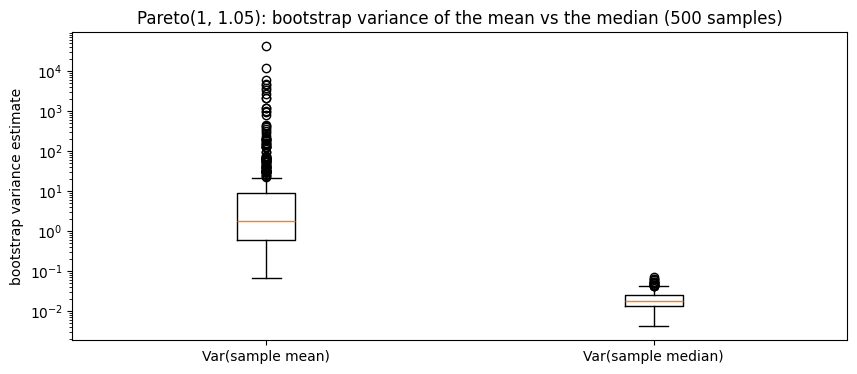

In [ ]:
reps = 500 # (4)+(5): a single sample is unstable when the
vm = np.empty(reps); vmd = np.empty(reps) # variance is infinite, so repeat over many samples
for i in range(reps):
    Xi = pareto_sample(n, k_par, beta, rng)
    vm[i]  = bootstrap_var(Xi, np.mean,   k=100)[1]
    vmd[i] = bootstrap_var(Xi, np.median, k=100)[1]

print(f"over {reps} fresh Pareto samples:")
print(f"  Var(mean):    median = {np.median(vm):7.2f}   (mean {vm.mean():.0f}, max {vm.max():.0f})")
print(f"  Var(median):  median = {np.median(vmd):7.4f}  (mean {vmd.mean():.4f}, max {vmd.max():.4f})")
print(f"  Var(mean) > Var(median) in {np.mean(vm > vmd) * 100:.0f}% of samples"
      f"   (typical ratio {np.median(vm / vmd):.0f})")

plt.boxplot([vm, vmd])
plt.xticks([1, 2], ["Var(sample mean)", "Var(sample median)"])
plt.yscale("log"); plt.ylabel("bootstrap variance estimate")
plt.title("Pareto(1, 1.05): bootstrap variance of the mean vs the median (500 samples)")
plt.show()

**Reading Part 3.** The sample median is far more precise: its bootstrap variance is small and stable,
whereas the mean's is large and wildly erratic from sample to sample. The reason is the underlying
distribution - with $k=1.05$ the Pareto has **infinite variance**, so a sample mean is dominated by rare
huge observations and inherits an enormous, unstable variance; the median ignores those extremes and
stays robust. This is exactly when the median (and the bootstrap) earn their keep.